In [1]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Results & Discussion (Summary)
</span></h3>

In [2]:
# Base directory where the CSV exports were saved
SAVE_DIR = os.path.normpath("../../data/Georgios/pcy_recommender")

# Load exported CSVs (@k = 6)
summary    = pd.read_csv(os.path.join(SAVE_DIR, "eval_comparison_k6.csv"))
adaptive_p = pd.read_csv(os.path.join(SAVE_DIR, "adaptive_precision.csv"))
adaptive_f = pd.read_csv(os.path.join(SAVE_DIR, "adaptive_fbeta_b1.csv"))
seg_p      = pd.read_csv(os.path.join(SAVE_DIR, "seg_alpha_precision.csv"))
seg_f      = pd.read_csv(os.path.join(SAVE_DIR, "seg_alpha_fbeta_b1.csv"))

print("=== NOVEL/REPEAT/HYBRID @k=6 ===")
print(summary.to_string(index=False))

print("\n=== Segment α (precision vs Fβ) ===")
print("precision:", dict(zip(seg_p.segment, seg_p.alpha)))
print("Fβ:",        dict(zip(seg_f.segment, seg_f.alpha)))

def _mean_safe(s) -> float:
    """Safe mean: ignore NaNs and return NaN if everything is missing."""
    s = pd.Series(s).dropna()
    return float(s.mean()) if not s.empty else float("nan")

print("\nMeans of per-user best metrics:")
means_df = pd.DataFrame([
    {
        "run": "precision",
        "mean_best_precision": _mean_safe(adaptive_p.best_precision),
        "mean_best_novelty":   _mean_safe(adaptive_p.best_novelty),
    },
    {
        "run": "fbeta(β=1.0)",
        "mean_best_precision": _mean_safe(adaptive_f.best_precision),
        "mean_best_novelty":   _mean_safe(adaptive_f.best_novelty),
    },
]).round(4)

print(means_df.to_string(index=False))

=== NOVEL/REPEAT/HYBRID @k=6 ===
 alpha  Precision@6  Coverage@6  Novelty@6     F0.5
  0.00     0.860250         1.0   0.061667 0.239624
  0.05     0.845667         1.0   0.076667 0.281318
  0.10     0.835250         1.0   0.087333 0.307894
  0.15     0.820167         1.0   0.102833 0.342430
  0.20     0.797250         1.0   0.126083 0.386145
  0.25     0.768083         1.0   0.155667 0.429858
  0.30     0.726667         1.0   0.198500 0.474277
  0.35     0.680667         1.0   0.245417 0.502447
  0.40     0.637583         1.0   0.289083 0.513722
  0.45     0.596333         1.0   0.330833 0.513857
  0.50     0.556667         1.0   0.371083 0.506050
  0.55     0.514917         1.0   0.413833 0.490933
  0.60     0.465000         1.0   0.464417 0.464883
  0.65     0.416250         1.0   0.513750 0.432673
  0.70     0.362667         1.0   0.568000 0.390931
  0.75     0.319000         1.0   0.612500 0.352812
  0.80     0.281917         1.0   0.650000 0.317924
  0.85     0.251333         1.0

=== ANALYSIS REPORT ===
SAVE_DIR: ..\..\data\Georgios\pcy_recommender

--- NOVEL / REPEAT / HYBRID @k=6 ---
Strategy  alpha  Precision@6  Coverage@6  Novelty@6
       0   0.00       0.8602         1.0     0.0617
       1   0.05       0.8457         1.0     0.0767
       2   0.10       0.8352         1.0     0.0873
       3   0.15       0.8202         1.0     0.1028
       4   0.20       0.7972         1.0     0.1261
       5   0.25       0.7681         1.0     0.1557
       6   0.30       0.7267         1.0     0.1985
       7   0.35       0.6807         1.0     0.2454
       8   0.40       0.6376         1.0     0.2891
       9   0.45       0.5963         1.0     0.3308
      10   0.50       0.5567         1.0     0.3711
      11   0.55       0.5149         1.0     0.4138
      12   0.60       0.4650         1.0     0.4644
      13   0.65       0.4162         1.0     0.5138
      14   0.70       0.3627         1.0     0.5680
      15   0.75       0.3190         1.0     0.6125
      16

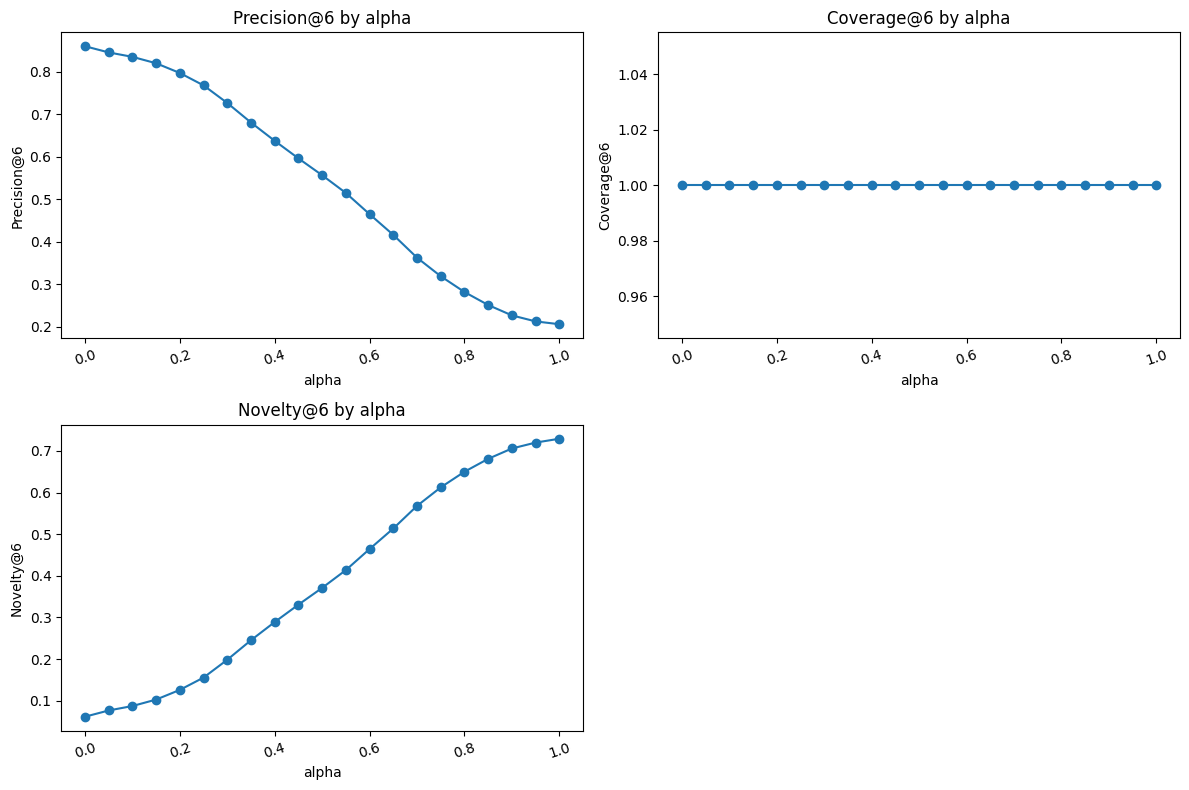


--- Segment α (precision vs Fβ=1.0) ---
 segment  alpha_precision  alpha_fbeta  delta
explorer              0.0          0.4    0.4

[NOTE] Segment alpha (precision) bars are all 0.0 — optimizing pure precision picked α=0 across segments, so the plot appears empty (zero-height bars).

--- Means of per-user best metrics ---
         run  mean_best_precision  mean_best_novelty
   precision               0.8633             0.0612
fbeta(β=1.0)               0.5520             0.3781


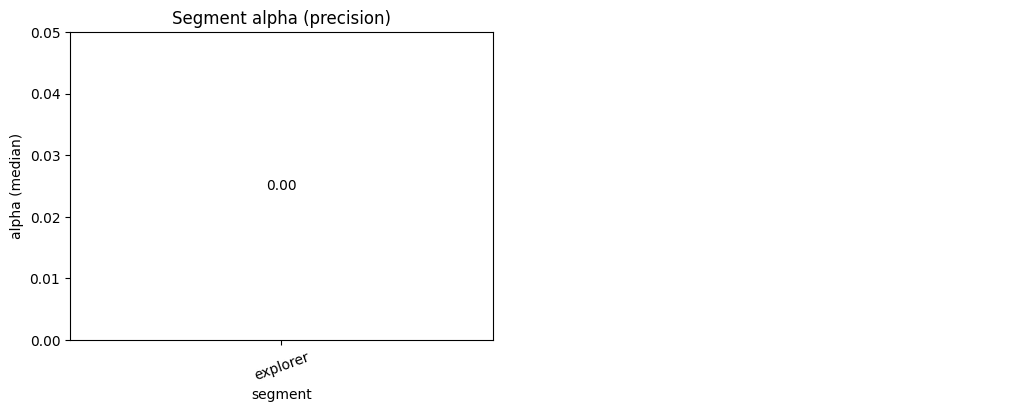

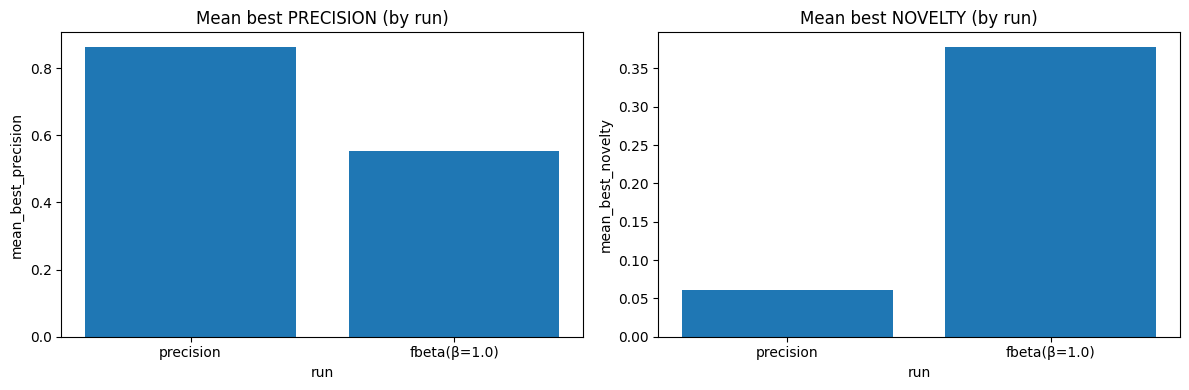


=== End of analysis ===


In [3]:
# ---------- Helpers ----------
def _mean_safe(s):
    s = pd.Series(s).dropna()
    return float(s.mean()) if not s.empty else float("nan")

def _load_csv(name):
    path = os.path.join(SAVE_DIR, name)
    if not os.path.exists(path):
        print(f"[WARN] Missing file: {path}")
        return None
    try:
        df = pd.read_csv(path)
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"[ERROR] Failed to read {path}: {e}")
        return None

def _ensure_strategy_col(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    out = df.copy()
    if "Strategy" in out.columns:
        return out
    if out.index.name and out.index.name.strip().lower() == "strategy":
        out = out.reset_index()
        out.rename(columns={out.columns[0]: "Strategy"}, inplace=True)
        return out
    like = [c for c in out.columns if str(c).strip().lower().startswith("strategy")]
    if like:
        out = out.rename(columns={like[0]: "Strategy"})
        return out
    out.insert(0, "Strategy", out.index.astype(str))
    return out.reset_index(drop=True)

def _grid(n, cols=2):
    rows = (n + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axs = np.atleast_1d(axs).ravel()
    return fig, axs, rows, cols

# Αν δεν έχεις ήδη ορίσει SAVE_DIR πιο πάνω στο notebook:
# SAVE_DIR = os.path.normpath("../../data/Georgios/pcy_recommender")

# Load data (προσαρμοσμένα για k=6)
summary    = _load_csv("eval_comparison_k6.csv")
adaptive_p = _load_csv("adaptive_precision.csv")
adaptive_f = _load_csv("adaptive_fbeta_b1.csv")
seg_p      = _load_csv("seg_alpha_precision.csv")
seg_f      = _load_csv("seg_alpha_fbeta_b1.csv")

print("=== ANALYSIS REPORT ===")
print(f"SAVE_DIR: {SAVE_DIR}")

#  1) NOVEL vs REPEAT vs HYBRID summary 
if summary is None or summary.empty:
    print("\n[INFO] No evaluation summary found.")
else:
    summary = _ensure_strategy_col(summary)

    # Columns που περιμένουμε να υπάρχουν στο CSV
    wanted = ["Strategy", "alpha", "HitRate@6", "NDCG@6", "Precision@6",
              "Coverage@6", "Novelty@6", "Diversity@6"]
    cols   = [c for c in wanted if c in summary.columns]

    # numeric metrics (ό,τι δεν είναι Strategy/alpha)
    num_cols = [c for c in cols if c not in ("Strategy", "alpha")]
    for c in num_cols:
        summary[c] = pd.to_numeric(summary[c], errors="coerce")

    print("\n--- NOVEL / REPEAT / HYBRID @k=6 ---")
    lead = [c for c in ["Strategy", "alpha"] if c in cols]
    print(summary[lead + num_cols].round(4).to_string(index=False))

    # x axis: είτε curve vs alpha (αν υπάρχει col alpha), είτε bars per Strategy
    is_alpha_table = ("alpha" in summary.columns)
    metrics = num_cols

    fig, axs, _, _ = _grid(len(metrics), cols=2)
    for i, metric in enumerate(metrics):
        ax = axs[i]
        if is_alpha_table:
            x = pd.to_numeric(summary["alpha"], errors="coerce")
            y = pd.to_numeric(summary[metric], errors="coerce").fillna(0)
            ax.plot(x, y, marker="o")
            ax.set_xlabel("alpha")
            ax.set_title(f"{metric} by alpha")
        else:
            ax.bar(summary["Strategy"], summary[metric].fillna(0))
            ax.set_xlabel("Strategy")
            ax.set_title(f"{metric} by Strategy")
        ax.set_ylabel(metric)
        for t in ax.get_xticklabels():
            t.set_rotation(18)

    for j in range(len(metrics), len(axs)):
        axs[j].axis("off")
    plt.tight_layout()
    plt.show()

#  2) Segment α comparison 
have_seg = (
    seg_p is not None and seg_f is not None and
    not seg_p.empty and not seg_f.empty and
    {"segment", "alpha"}.issubset(seg_p.columns) and
    {"segment", "alpha"}.issubset(seg_f.columns)
)

if have_seg:
    print("\n--- Segment α (precision vs Fβ=1.0) ---")
    segs = sorted(set(seg_p["segment"]).union(set(seg_f["segment"])))
    left  = {r["segment"]: r["alpha"] for _, r in seg_p.iterrows()}
    right = {r["segment"]: r["alpha"] for _, r in seg_f.iterrows()}
    cmp = pd.DataFrame({
        "segment": segs,
        "alpha_precision": [left.get(s, np.nan) for s in segs],
        "alpha_fbeta":     [right.get(s, np.nan) for s in segs],
    })
    cmp["delta"] = (cmp["alpha_fbeta"] - cmp["alpha_precision"]).round(3)
    print(cmp.to_string(index=False))

    fig, axs, _, _ = _grid(2, cols=2)

    # precision chart με zero-baseline & labels όταν όλα είναι 0
    ap = pd.to_numeric(cmp["alpha_precision"], errors="coerce")
    axs[0].bar(cmp["segment"], ap.fillna(0))
    axs[0].set_title("Segment alpha (precision)")
    axs[0].set_xlabel("segment")
    axs[0].set_ylabel("alpha (median)")
    axs[0].tick_params(axis='x', rotation=20)

    max_ap = np.nanmax(ap.values) if len(ap) else 0.0
    if not np.isfinite(max_ap) or max_ap == 0.0:
        axs[0].set_ylim(0, 0.05)
        for i, seg in enumerate(cmp["segment"]):
            axs[0].text(i, 0.025, "0.00", ha="center", va="center")

    # (αν θέλεις μπορείς να χρησιμοποιήσεις τον 2ο ax για άλλο plot, προς το παρόν μένει κενός)
    axs[1].axis("off")

    if np.nanmax(ap.values) == 0.0:
        print("\n[NOTE] Segment alpha (precision) bars are all 0.0 — "
              "optimizing pure precision picked α=0 across segments, "
              "so the plot appears empty (zero-height bars).")
else:
    print("\n[INFO] Segment-alpha CSVs not found or missing columns; skipping segment comparison.")

#  3) Means of per-user “best” metrics (precision vs Fβ) 
ok_p = adaptive_p is not None and not adaptive_p.empty
ok_f = adaptive_f is not None and not adaptive_f.empty

if ok_p and ok_f:
    mp  = round(_mean_safe(adaptive_p.get("best_precision")), 4)
    npv = round(_mean_safe(adaptive_p.get("best_novelty")), 4)
    mf  = round(_mean_safe(adaptive_f.get("best_precision")), 4)
    nf  = round(_mean_safe(adaptive_f.get("best_novelty")), 4)

    means_df = pd.DataFrame([
        {"run": "precision",    "mean_best_precision": mp, "mean_best_novelty": npv},
        {"run": "fbeta(β=1.0)", "mean_best_precision": mf, "mean_best_novelty": nf},
    ])

    print("\n--- Means of per-user best metrics ---")
    print(means_df.to_string(index=False))

    fig, axs, _, _ = _grid(2, cols=2)
    axs[0].bar(means_df["run"], means_df["mean_best_precision"])
    axs[0].set_title("Mean best PRECISION (by run)")
    axs[0].set_xlabel("run")
    axs[0].set_ylabel("mean_best_precision")

    axs[1].bar(means_df["run"], means_df["mean_best_novelty"])
    axs[1].set_title("Mean best NOVELTY (by run)")
    axs[1].set_xlabel("run")
    axs[1].set_ylabel("mean_best_novelty")

    plt.tight_layout()
    plt.show()
else:
    print("\n[INFO] Adaptive-run CSVs not found; skipping means section.")

print("\n=== End of analysis ===")
